# Tarea 2 — Convolución de señales acústicas

## Objetivo

Comprender cómo una respuesta al impulso modifica una señal acústica mediante convolución.

In [1]:
# 1. Importar librerías

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
from scipy.signal import fftconvolve
from IPython.display import Audio, display

In [2]:
# 2. Rutas de audio
ruta_voz = Path("../assets/audio/ocarina_anecoica_00.wav")
ruta_ir = Path("../assets/audio/sala_11101_fuente2_mic3_00.wav")
ruta_salida = Path("../assets/audio/ocarina_convolucion_demo_02.wav")

print("Ruta voz:", ruta_voz)
print("Ruta IR:", ruta_ir)

# Verificar que existan
assert ruta_voz.exists(), f"No existe el archivo: {ruta_voz}"
assert ruta_ir.exists(), f"No existe el archivo: {ruta_ir}"

Ruta voz: ..\assets\audio\ocarina_anecoica_00.wav
Ruta IR: ..\assets\audio\sala_11101_fuente2_mic3_00.wav


In [3]:
# 3. Cargar archivos y ajustar señales

# Cargar archivos
voz, fs_voz = sf.read(ruta_voz)
ir, fs_ir = sf.read(ruta_ir)

# ---------------------------------------------------------
# Ajuste de canales (mono)
# ---------------------------------------------------------
if voz.ndim > 1:
    voz = voz.mean(axis=1)

if ir.ndim > 1:
    ir = ir.mean(axis=1)

# ---------------------------------------------------------
# Ajuste de frecuencia de muestreo
# ---------------------------------------------------------
if fs_voz != fs_ir:
    print("Las frecuencias no coinciden. Remuestreando voz...")
    voz = librosa.resample(
        voz.astype(float),
        orig_sr=fs_voz,
        target_sr=fs_ir
    )
    fs_voz = fs_ir

# ---------------------------------------------------------
# Verificación final
# ---------------------------------------------------------
print("Frecuencia de muestreo voz:", fs_voz)
print("Frecuencia de muestreo impulso:", fs_ir)

assert fs_voz == fs_ir, "Las frecuencias de muestreo deben coincidir"

Frecuencia de muestreo voz: 44100
Frecuencia de muestreo impulso: 44100


## ¿Qué estamos haciendo?

Estamos simulando cómo se escucha una señal dentro de un recinto.

Matemáticamente:

$y(t) = x(t) * h(t)$

- $x(t)$: señal anecoica (voz)
- $h(t)$: respuesta al impulso
- $y(t)$: señal resultante

## Interpretación del sistema

En este experimento, el recinto se modela como un sistema lineal e invariante en el tiempo (LTI).

La respuesta al impulso contiene toda la información del sistema.

Por lo tanto, al convolucionar una señal con la respuesta al impulso, obtenemos cómo el sistema modifica la señal.

In [4]:
# 5. Convolución

y = fftconvolve(voz, ir, mode="full")

# Normalizar para evitar clipping
if np.max(np.abs(y)) > 0:
    y = y / np.max(np.abs(y))

## Resultado de la convolución

La señal resultante representa cómo se escucharía la voz dentro del recinto.

In [5]:
# 6. Ejes de tiempo

t_voz = np.arange(len(voz)) / fs_voz
t_ir = np.arange(len(ir)) / fs_ir
t_y = np.arange(len(y)) / fs_voz

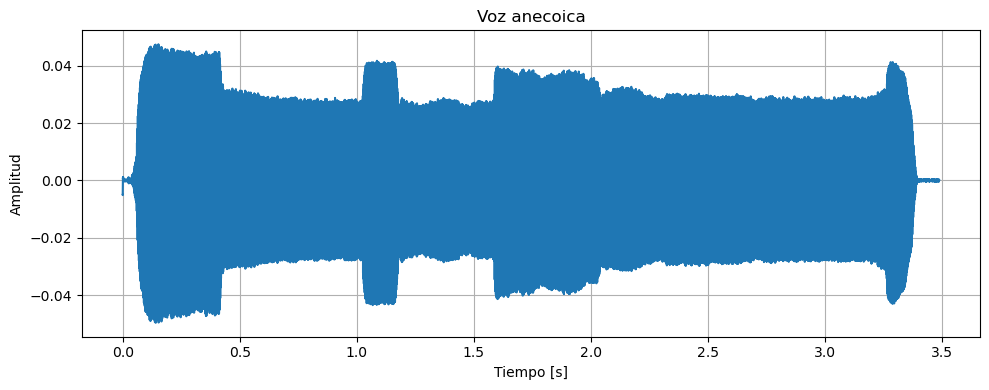

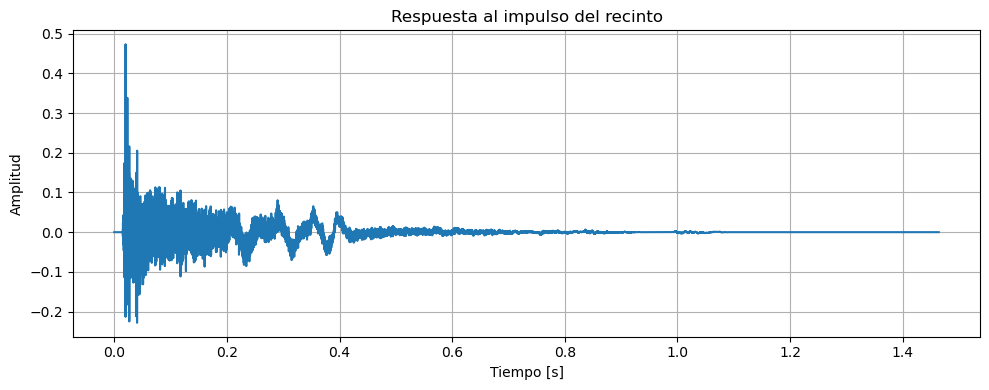

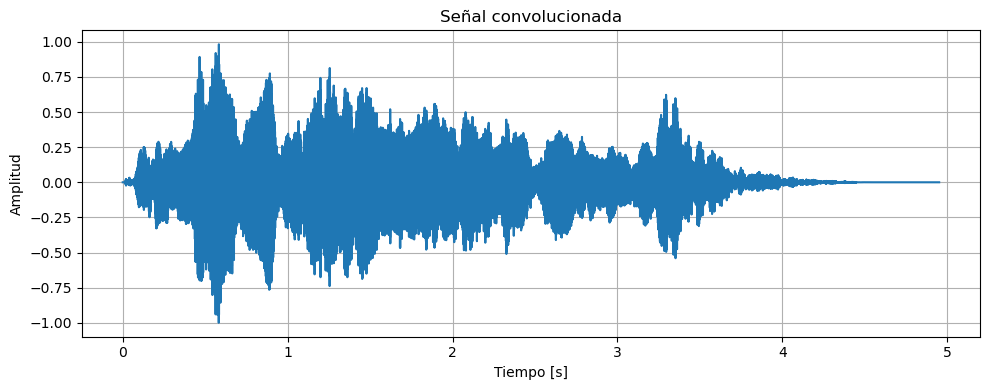

In [6]:
# 7. Gráficos

plt.figure(figsize=(10, 4))
plt.plot(t_voz, voz)
plt.title("Voz anecoica")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_ir, ir)
plt.title("Respuesta al impulso del recinto")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_y, y)
plt.title("Señal convolucionada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.tight_layout()
plt.show()

## Preguntas de análisis

1. ¿Qué diferencias auditivas percibes entre la voz original y la convolucionada?

2. ¿La señal convolucionada presenta mayor reverberación? Describe.

3. ¿Cómo afecta la respuesta al impulso a la inteligibilidad de la voz?

4. ¿Qué características del recinto crees que están presentes en la respuesta al impulso?

5. ¿Qué ocurriría si la respuesta al impulso fuese más corta o más larga?

In [7]:
# 8. Comparación auditiva

print("Voz original:")
display(Audio(voz, rate=fs_voz))

print("Respuesta al impulso:")
display(Audio(ir, rate=fs_ir))

print("Voz convolucionada:")
display(Audio(y, rate=fs_voz))


Voz original:


Respuesta al impulso:


Voz convolucionada:


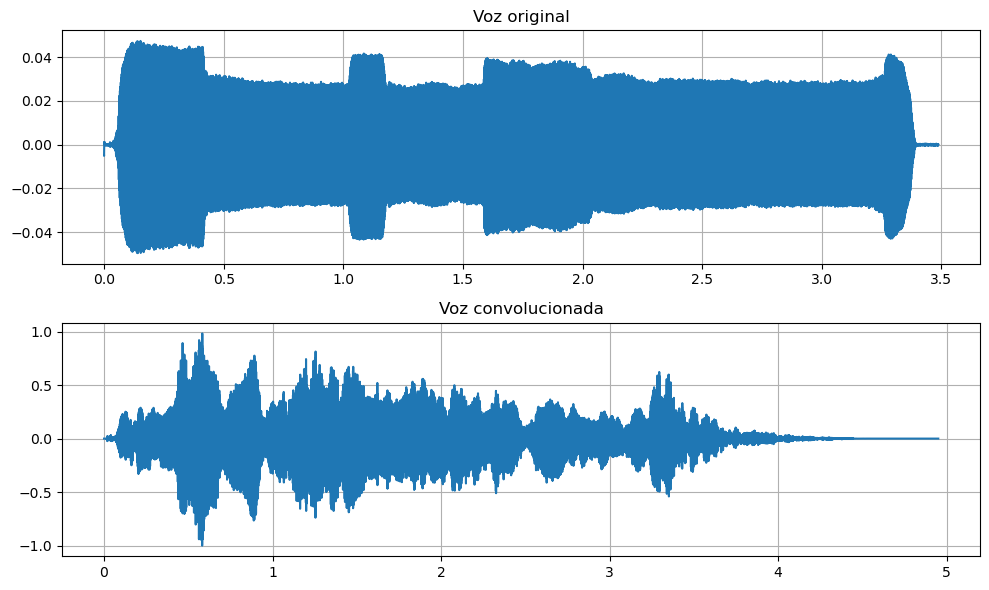

In [8]:
# 9. Comparación visual directa

fig, axs = plt.subplots(2, 1, figsize=(10, 6))

axs[0].plot(t_voz, voz)
axs[0].set_title("Voz original")
axs[0].grid()

axs[1].plot(t_y, y)
axs[1].set_title("Voz convolucionada")
axs[1].grid()

plt.tight_layout()
plt.show()

In [9]:
# 10. Guardar salida

if np.max(np.abs(y)) > 0:
    y = y / np.max(np.abs(y))

sf.write(ruta_salida, y, fs_voz)
print("Archivo guardado en:", ruta_salida)

Archivo guardado en: ..\assets\audio\ocarina_convolucion_demo_02.wav
